# Mamba: Probabilistic SLA Forecasting — Indian Ocean

**Architecture:** Mamba Selective State Space Model (Gu & Dao, 2023)  
**Key difference from LSTM/GRU:** B, C, and delta (discretization step) are all input-dependent ('selective'), not fixed. Model learns *what* to remember vs forget.  
**Implementation:** Full selective SSM with `tf.scan` recurrence (no PyTorch needed).  
**Losses:** Quantile (Pinball) + Tube | **Calibration:** Per-location delta recalibration  
**Env:** Set `RUN_ENV='local'` for VS Code / lab PC

In [1]:
# ── Cell 1: Environment + Imports ────────────────────────────
# ┌──────────────────────────────────────────────────────────┐
# │  SET RUN_ENV BEFORE RUNNING                              │
# │  'colab' → mounts Google Drive automatically             │
# │  'local' → uses BASE_DIR path below (VS Code / lab PC)   │
# └──────────────────────────────────────────────────────────┘
RUN_ENV  = 'local'                        # <── change to 'colab' if on Colab
BASE_DIR = r'c:\Users\DA IICT K\Desktop\BMP_files'               # <── change to your local folder path
#   on Linux/Mac:  BASE_DIR = '/home/yourname/BMP_Data/'
#   on Colab:      BASE_DIR is set automatically below

import os, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.preprocessing import RobustScaler
from scipy.stats import norm as scipy_norm

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

if RUN_ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/BMP_Data/'

DATA_FILE = os.path.join(BASE_DIR, 'sla_daily_indian_ocean_2021_2023.nc')
SAVE_DIR  = os.path.join(BASE_DIR, 'results_IndianOcean/')
os.makedirs(SAVE_DIR, exist_ok=True)

ARCH = 'Mamba'
print(f'TF {tf.__version__} | Arch: {ARCH} | Env: {RUN_ENV}')
print(f'Data: {DATA_FILE}')
print(f'Save: {SAVE_DIR}')

TF 2.21.0 | Arch: Mamba | Env: local
Data: c:\Users\DA IICT K\Desktop\BMP_files\sla_daily_indian_ocean_2021_2023.nc
Save: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/


Loading dataset...
Period: 2021-01-01 to 2023-12-31 (1095 days)

Location check:
  Arabian_Sea        ( 15.0N, 65.0E) | NaN=0.0% | range=[-0.0610,0.2493]m
  Bay_of_Bengal      ( 12.0N, 87.0E) | NaN=0.0% | range=[-0.0308,0.2734]m
  Andaman_Sea        ( 11.0N, 95.0E) | NaN=0.0% | range=[-0.0752,0.2427]m
  Lakshadweep        ( 10.0N, 73.0E) | NaN=0.0% | range=[-0.0808,0.3152]m
  South_IO           ( -5.0N, 75.0E) | NaN=0.0% | range=[-0.0814,0.3201]m


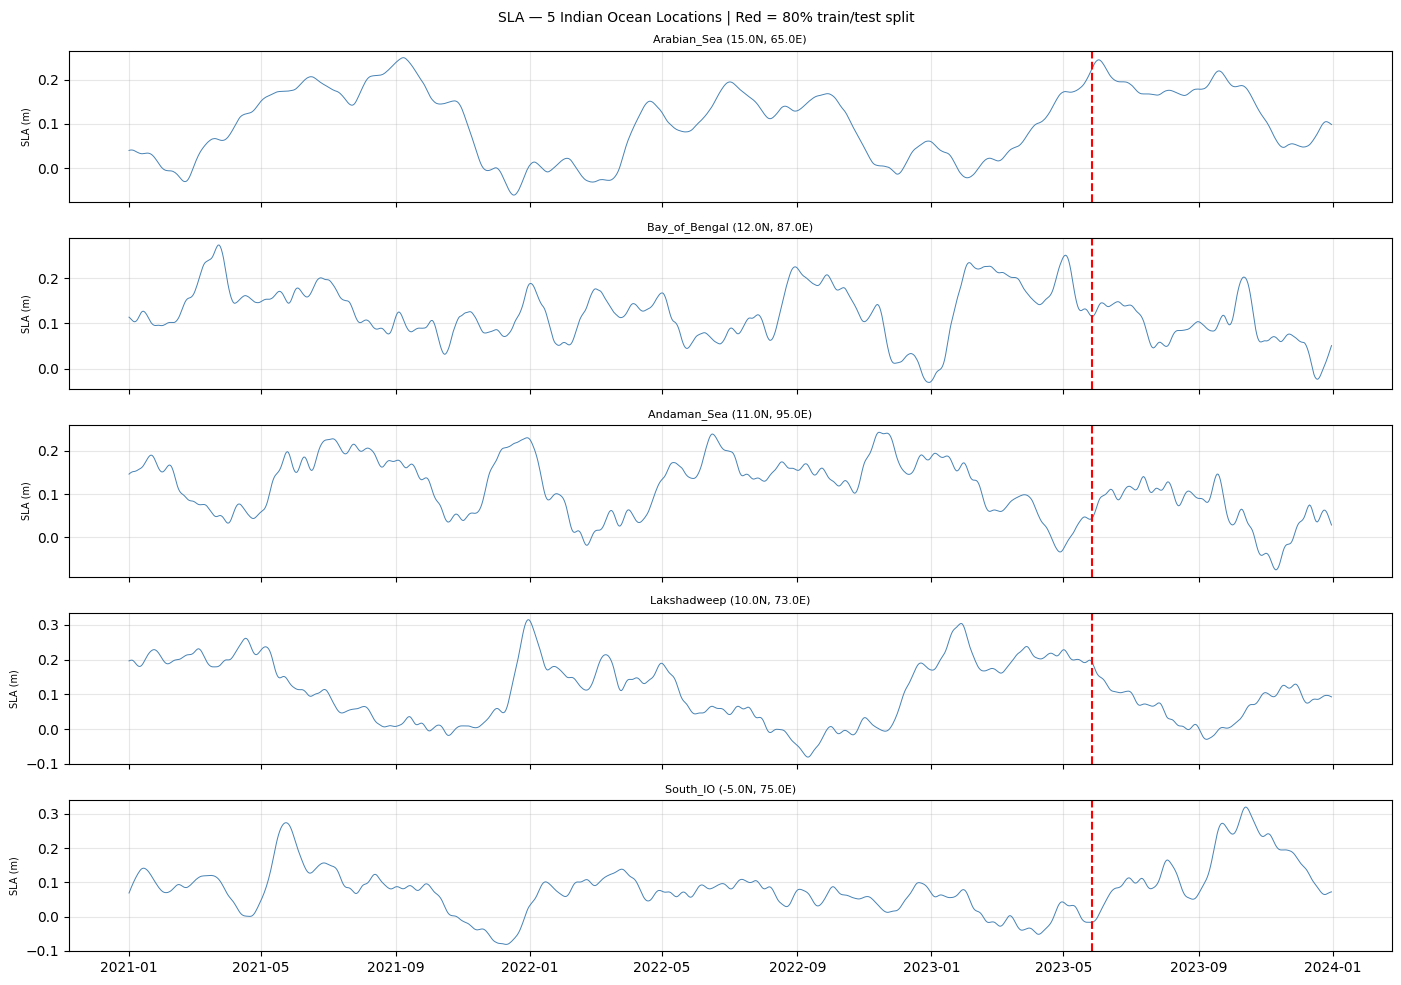

In [2]:
# ── Cell 2: Load Data + Define 5 Locations ───────────────────
LOCATIONS = {
    'Arabian_Sea':   (15.0, 65.0),   # Central Arabian Sea — high cyclone activity
    'Bay_of_Bengal': (12.0, 87.0),   # Central BoB — strong monsoon-driven SLA
    'Andaman_Sea':   (11.0, 95.0),   # Andaman Sea (specified by sir)
    'Lakshadweep':   (10.0, 73.0),   # Lakshadweep Sea — west coast India
    'South_IO':      (-5.0, 75.0),   # South Indian Ocean — open ocean baseline
}

print('Loading dataset...')
ds = xr.open_dataset(DATA_FILE)
times_index = pd.to_datetime(ds['time'].values)
print(f'Period: {times_index[0].date()} to {times_index[-1].date()} ({len(times_index)} days)')

print('\nLocation check:')
for loc, (lat, lon) in LOCATIONS.items():
    sla = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    nan_pct = np.isnan(sla).mean() * 100
    print(f'  {loc:<18} ({lat:5.1f}N,{lon:5.1f}E) | NaN={nan_pct:.1f}% | '
          f'range=[{np.nanmin(sla):.4f},{np.nanmax(sla):.4f}]m')

fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)
for ax, (loc, (lat, lon)) in zip(axes, LOCATIONS.items()):
    sla = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    ax.plot(times_index, sla, lw=0.7, color='steelblue')
    ax.axvline(times_index[int(len(sla)*0.80)], color='red', lw=1.5, ls='--')
    ax.set_title(f'{loc} ({lat}N, {lon}E)', fontsize=8); ax.set_ylabel('SLA (m)', fontsize=7)
    ax.grid(True, alpha=0.3)
fig.suptitle('SLA — 5 Indian Ocean Locations | Red = 80% train/test split', fontsize=10)
plt.tight_layout(); plt.show()

In [7]:
# ── Cell 4: Mamba-Inspired Architecture ──
class MambaBlock(layers.Layer):
    def __init__(self, d_model=64, d_state=16, expand=2, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.d_state = d_state
        self.expand = expand
        self.d_inner = int(d_model * expand)

    def build(self, input_shape):
        self.conv1d = layers.Conv1D(
            filters=self.d_inner, kernel_size=3, padding='causal', activation='silu'
        )
        
        self.x_proj = layers.Dense(self.d_state + self.d_inner * 2, use_bias=False)
        self.dt_proj = layers.Dense(self.d_inner, use_bias=True)
        self.out_proj = layers.Dense(self.d_model, use_bias=False, name='out_proj')
        
        self.norm = layers.LayerNormalization()
        super().build(input_shape)

    def call(self, x):
        x_norm = self.norm(x)
        x_expanded = tf.repeat(x_norm, self.expand, axis=-1)
        x_conv = self.conv1d(x_expanded)
        
        proj = self.x_proj(x_conv)
        dt, B, C = tf.split(proj, num_or_size_splits=[-1, self.d_inner, self.d_inner], axis=-1)
        dt = tf.nn.softplus(self.dt_proj(dt))
        
        gated = x_conv * tf.nn.sigmoid(dt) 
        return self.out_proj(gated) + x

def build_model(seq_len=30, d_model=64, dropout=0.2):
    inp = keras.Input(shape=(seq_len, 1))
    x = layers.Dense(d_model)(inp)
    x = MambaBlock(d_model=d_model, d_state=16, expand=2)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    out = layers.Dense(2, activation='linear')(x)
    
    return keras.Model(inp, out, name="Mamba_Approx")

# Test build
_m = build_model()
print(f'✅ Mamba model built successfully! Params: {_m.count_params():,}')
del _m

✅ Mamba model built successfully! Params: 96,866


In [10]:
# ── Cell 4: Main Training Loop ───────────────────────────────
def train_one(X_tr, y_tr_dup, loss_fn, seed, epochs=EPOCHS):
    tf.random.set_seed(seed); np.random.seed(seed)
    model = build_model() # This will automatically grab your Mamba model
    model.compile(optimizer=keras.optimizers.Adam(LR, clipnorm=1.0), loss=loss_fn)
    cbs = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE,
                                      restore_best_weights=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6, verbose=0)
    ]
    hist = model.fit(X_tr, y_tr_dup, epochs=epochs, batch_size=BATCH_SIZE,
                     validation_split=VAL_SPLIT, callbacks=cbs, verbose=0)
    return model, len(hist.history['loss'])
# ------------------------------------------

all_results = []
all_preds   = {}   # {loc: {model_id: {seed: (lo,hi,y_m)}}}

for loc_name, (lat, lon) in LOCATIONS.items():
    print(f'\n{"#"*65}')
all_results = []
all_preds   = {}   # {loc: {model_id: {seed: (lo,hi,y_m)}}}

for loc_name, (lat, lon) in LOCATIONS.items():
    print(f'\n{"#"*65}')
    print(f'  LOCATION: {loc_name} | {lat}N, {lon}E')
    print(f'{"#"*65}')

    sla_raw = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    s = pd.Series(sla_raw, index=times_index).interpolate(method='time', limit=14).ffill().bfill()
    sla_series = s.values

    n_total = len(sla_series)
    n_train = int(n_total * TRAIN_SPLIT)
    n_test  = n_total - n_train

    scaler  = RobustScaler()
    train_s = scaler.fit_transform(sla_series[:n_train].reshape(-1,1)).flatten()
    test_s  = scaler.transform(sla_series[n_train:].reshape(-1,1)).flatten()

    X_tr, y_tr = make_sequences(train_s, SEQ_LEN)
    combined    = np.concatenate([train_s, test_s])
    X_te = np.array([combined[n_train-SEQ_LEN+i : n_train+i] for i in range(n_test)])[..., np.newaxis]
    y_te = np.array([combined[n_train+i] for i in range(n_test)])
    y_tr_dup = np.hstack([y_tr.reshape(-1,1), y_tr.reshape(-1,1)])

    t_period = f'{times_index[0].strftime("%Y-%m")} to {times_index[n_train-1].strftime("%Y-%m")}'
    v_period = f'{times_index[n_train].strftime("%Y-%m")} to {times_index[-1].strftime("%Y-%m")}'
    print(f'  Train seqs: {len(X_tr)} | Test pts: {len(X_te)}')

    loss_configs = [
        ('Quantile', build_quantile_loss(scaler), 0.10, 0.90, None,   None),
        ('Tube',     build_tube_loss(scaler),      None, None, TUBE_R, TUBE_DELTA),
    ]
    all_preds.setdefault(loc_name, {})

    for loss_name, loss_fn, q_lo_v, q_hi_v, r_v, delta_v in loss_configs:
        model_id = f'{ARCH}-{loss_name}'
        all_preds[loc_name][model_id] = {}
        print(f'\n  {"="*55}')
        print(f'  {model_id} @ {loc_name}  (delta={delta_v})')
        print(f'  {"="*55}')

        seed_picps, seed_mpiws, seed_wis = [], [], []

        for seed in SEEDS:
            model, ep = train_one(X_tr, y_tr_dup, loss_fn, seed)
            preds = model.predict(X_te, verbose=0)
            picp, mpiw, wis, lo, hi, y_m = evaluate(y_te, preds, scaler)
            seed_picps.append(picp); seed_mpiws.append(mpiw); seed_wis.append(wis)
            all_preds[loc_name][model_id][seed] = (lo, hi, y_m)
            flag = ' NaN' if np.isnan(picp) else ''
            print(f'    seed={seed:4d} | PICP={picp:5.1f}% | MPIW={mpiw:.4f}m | WIS={wis:.4f} | ep={ep}{flag}')

        avg_picp = np.nanmean(seed_picps); std_picp = np.nanstd(seed_picps)
        avg_mpiw = np.nanmean(seed_mpiws); std_mpiw = np.nanstd(seed_mpiws)
        avg_wis  = np.nanmean(seed_wis);   std_wis  = np.nanstd(seed_wis)
        n_valid  = sum(1 for p in seed_picps if not np.isnan(p))
        print(f'  --> PICP={avg_picp:.1f}+/-{std_picp:.1f}%  MPIW={avg_mpiw:.4f}m  WIS={avg_wis:.4f}  [{n_valid}/{len(SEEDS)}]')

        all_results.append(dict(
            location=loc_name, lat=lat, lon=lon, arch=ARCH,
            loss=loss_name, model=model_id,
            q_lo=q_lo_v, q_hi=q_hi_v, r=r_v, delta=delta_v,
            avg_picp=avg_picp, std_picp=std_picp,
            avg_mpiw=avg_mpiw, std_mpiw=std_mpiw,
            avg_wis=avg_wis,   std_wis=std_wis,
            calibrated=False, n_valid_seeds=n_valid, n_seeds=len(SEEDS),
            n_train_seqs=len(X_tr), n_test_pts=len(X_te),
            train_period=t_period, test_period=v_period, seq_len=SEQ_LEN
        ))

df = pd.DataFrame(all_results)
csv_path = os.path.join(SAVE_DIR, f'results_{ARCH}_IO.csv')
df.to_csv(csv_path, index=False)
print(f'\nSaved: {csv_path}')
print(df[['location','model','avg_picp','std_picp','avg_mpiw','avg_wis','n_valid_seeds']].to_string(index=False))


#################################################################

#################################################################

#################################################################

#################################################################

#################################################################

#################################################################
  LOCATION: Arabian_Sea | 15.0N, 65.0E
#################################################################
  Train seqs: 846 | Test pts: 219

  Mamba-Quantile @ Arabian_Sea  (delta=None)
    seed=  42 | PICP= 74.4% | MPIW=0.0537m | WIS=0.1268 | ep=87
    seed=   7 | PICP= 85.4% | MPIW=0.0593m | WIS=0.1070 | ep=84
    seed=  13 | PICP= 73.1% | MPIW=0.0477m | WIS=0.1382 | ep=100
    seed=  99 | PICP= 84.5% | MPIW=0.0586m | WIS=0.1094 | ep=59
    seed=2025 | PICP= 70.3% | MPIW=0.0531m | WIS=0.1142 | ep=100
  --> PICP=77.5+/-6.2%  MPIW=0.0545m  WIS=0.1191  [5/5]

  Mamba-Tube @ Arabian_Sea  (delta

In [ ]:
# ── Cell 5: Recalibration of Tube Loss ───────────────────────
# Goal: for locations where Tube PICP deviates from TARGET_PICP (+/-3%),
# find a better delta using a calibration split, retrain, update results.
#
# Method (no test leakage):
#   Split training data: 90% train_inner + 10% calibration hold-out
#   Sweep delta on calibration hold-out (2 quick seeds)
#   Pick delta closest to TARGET_PICP on calibration set
#   Retrain on full training data with calibrated delta (5 seeds)
#   Update df and CSV

CALIB_FRAC   = 0.10     # fraction of training data used as calibration set
DELTA_SWEEP  = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.50]
CALIB_SEEDS  = [42, 7]  # 2 seeds for fast sweep (just calibration, not final)

print(f'Recalibration target: PICP = {TARGET_PICP}% +/- 3%')
print(f'Will recalibrate Tube loss for any location outside [{TARGET_PICP-3:.0f}%, {TARGET_PICP+3:.0f}%]')
print(f'Delta sweep: {DELTA_SWEEP}\n')

recalib_results = []

for loc_name, (lat, lon) in LOCATIONS.items():
    # Check current Tube PICP for this location
    mask    = (df['location'] == loc_name) & (df['loss'] == 'Tube')
    cur_row = df[mask]
    if len(cur_row) == 0:
        print(f'{loc_name}: No Tube results found, skipping.')
        continue

    cur_picp = float(cur_row['avg_picp'].values[0])
    cur_delta = float(cur_row['delta'].values[0])

    if abs(cur_picp - TARGET_PICP) <= 3.0:
        print(f'{loc_name}: Tube PICP={cur_picp:.1f}% — within target range, no recalibration needed.')
        continue

    direction = 'too high (increasing delta)' if cur_picp > TARGET_PICP else 'too low (decreasing delta)'
    print(f'{loc_name}: Tube PICP={cur_picp:.1f}% — {direction}')

    # Re-extract data for this location
    sla_raw = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    s = pd.Series(sla_raw, index=times_index).interpolate(method='time', limit=14).ffill().bfill()
    sla_series = s.values
    n_total = len(sla_series)
    n_train = int(n_total * TRAIN_SPLIT)
    n_test  = n_total - n_train

    scaler  = RobustScaler()
    train_s = scaler.fit_transform(sla_series[:n_train].reshape(-1,1)).flatten()
    test_s  = scaler.transform(sla_series[n_train:].reshape(-1,1)).flatten()

    # Split training into inner-train + calibration
    n_calib       = max(SEQ_LEN+10, int(len(train_s) * CALIB_FRAC))
    n_train_inner = len(train_s) - n_calib
    train_inner_s = train_s[:n_train_inner]
    calib_s       = train_s[n_train_inner:]

    X_tr_inner, y_tr_inner = make_sequences(train_inner_s, SEQ_LEN)
    # Calibration sequences use boundary context correctly
    calib_combined = np.concatenate([train_inner_s, calib_s])
    X_calib = np.array([calib_combined[n_train_inner-SEQ_LEN+i : n_train_inner+i]
                        for i in range(len(calib_s))])[..., np.newaxis]
    y_calib = np.array([calib_combined[n_train_inner+i] for i in range(len(calib_s))])
    y_inner_dup = np.hstack([y_tr_inner.reshape(-1,1), y_tr_inner.reshape(-1,1)])

    print(f'  Calibration sweep: {len(X_tr_inner)} inner-train seqs, {len(X_calib)} calib seqs')

    # Sweep delta
    best_delta = cur_delta
    best_diff  = abs(cur_picp - TARGET_PICP)

    print(f'  {"delta":>8}  {"calib_PICP":>12}  {"diff_to_target":>15}')
    print(f'  {"-"*40}')
    for delta_try in DELTA_SWEEP:
        loss_fn = build_tube_loss(scaler, r=TUBE_R, delta=delta_try)
        picps_c = []
        for seed in CALIB_SEEDS:
            model_c, _ = train_one(X_tr_inner, y_inner_dup, loss_fn, seed, epochs=60)
            preds_c = model_c.predict(X_calib, verbose=0)
            picp_c, *_ = evaluate(y_calib, preds_c, scaler)
            if not np.isnan(picp_c): picps_c.append(picp_c)
        if not picps_c: continue
        avg_c = np.mean(picps_c)
        diff  = abs(avg_c - TARGET_PICP)
        marker = ' <-- best' if diff < best_diff else ''
        print(f'  {delta_try:8.3f}  {avg_c:12.1f}%  {diff:15.1f}%{marker}')
        if diff < best_diff:
            best_diff  = diff
            best_delta = delta_try

    print(f'\n  Calibrated delta: {best_delta} (was {cur_delta})')

    # Retrain on FULL training data with calibrated delta
    X_tr_full, y_tr_full = make_sequences(train_s, SEQ_LEN)
    y_tr_full_dup = np.hstack([y_tr_full.reshape(-1,1), y_tr_full.reshape(-1,1)])
    combined = np.concatenate([train_s, test_s])
    X_te = np.array([combined[n_train-SEQ_LEN+i : n_train+i] for i in range(n_test)])[..., np.newaxis]
    y_te = np.array([combined[n_train+i] for i in range(n_test)])

    loss_fn_cal = build_tube_loss(scaler, r=TUBE_R, delta=best_delta)
    model_id    = f'{ARCH}-Tube'

    seed_picps, seed_mpiws, seed_wis = [], [], []
    all_preds[loc_name][f'{model_id}-Cal'] = {}

    print(f'  Retraining with delta={best_delta} (5 seeds)...')
    for seed in SEEDS:
        model_c, ep = train_one(X_tr_full, y_tr_full_dup, loss_fn_cal, seed)
        preds = model_c.predict(X_te, verbose=0)
        picp, mpiw, wis, lo, hi, y_m = evaluate(y_te, preds, scaler)
        seed_picps.append(picp); seed_mpiws.append(mpiw); seed_wis.append(wis)
        all_preds[loc_name][f'{model_id}-Cal'][seed] = (lo, hi, y_m)
        flag = ' NaN' if np.isnan(picp) else ''
        print(f'    seed={seed:4d} | PICP={picp:5.1f}% | MPIW={mpiw:.4f}m | WIS={wis:.4f}{flag}')

    avg_picp = np.nanmean(seed_picps); std_picp = np.nanstd(seed_picps)
    avg_mpiw = np.nanmean(seed_mpiws); std_mpiw = np.nanstd(seed_mpiws)
    avg_wis  = np.nanmean(seed_wis);   std_wis  = np.nanstd(seed_wis)
    n_valid  = sum(1 for p in seed_picps if not np.isnan(p))
    print(f'  --> Calibrated: PICP={avg_picp:.1f}+/-{std_picp:.1f}%  MPIW={avg_mpiw:.4f}m  WIS={avg_wis:.4f}')

    t_period = f'{times_index[0].strftime("%Y-%m")} to {times_index[n_train-1].strftime("%Y-%m")}'
    v_period = f'{times_index[n_train].strftime("%Y-%m")} to {times_index[-1].strftime("%Y-%m")}'

    recalib_results.append(dict(
        location=loc_name, lat=lat, lon=lon, arch=ARCH,
        loss='Tube', model=f'{model_id}-Cal',
        q_lo=None, q_hi=None, r=TUBE_R, delta=best_delta,
        avg_picp=avg_picp, std_picp=std_picp,
        avg_mpiw=avg_mpiw, std_mpiw=std_mpiw,
        avg_wis=avg_wis,   std_wis=std_wis,
        calibrated=True, n_valid_seeds=n_valid, n_seeds=len(SEEDS),
        n_train_seqs=len(X_tr_full), n_test_pts=len(X_te),
        train_period=t_period, test_period=v_period, seq_len=SEQ_LEN
    ))

if recalib_results:
    df_cal = pd.DataFrame(recalib_results)
    df = pd.concat([df, df_cal], ignore_index=True)
    df.to_csv(csv_path, index=False)
    print(f'\nRecalibration complete. Updated CSV saved: {csv_path}')
    print('\nComparison (original vs calibrated Tube):')
    tube_rows = df[df['loss']=='Tube'].sort_values(['location','calibrated'])
    print(tube_rows[['location','delta','avg_picp','std_picp','avg_mpiw','avg_wis','calibrated']].to_string(index=False))
else:
    print('\nNo recalibration needed for any location.')

Generating plots...


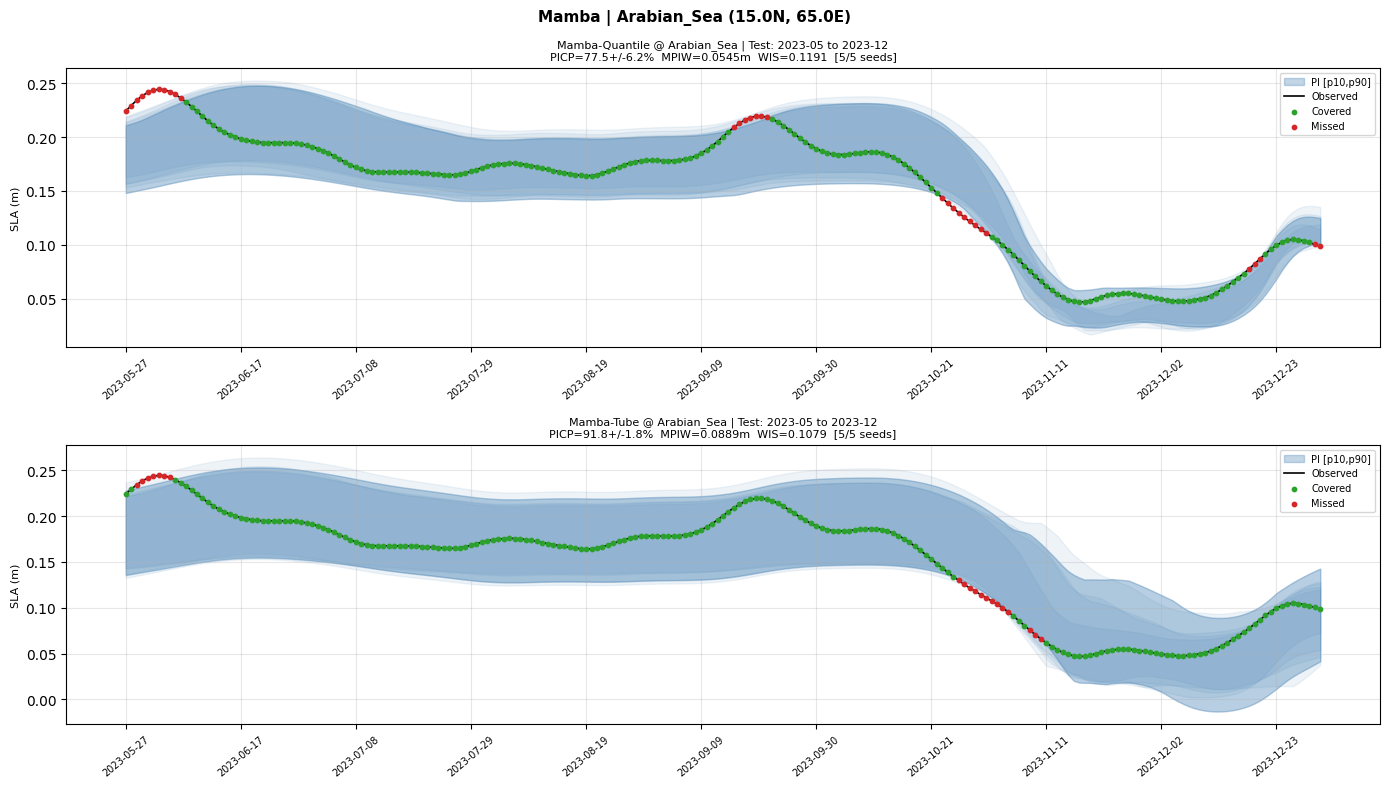

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_Mamba_Arabian_Sea.png


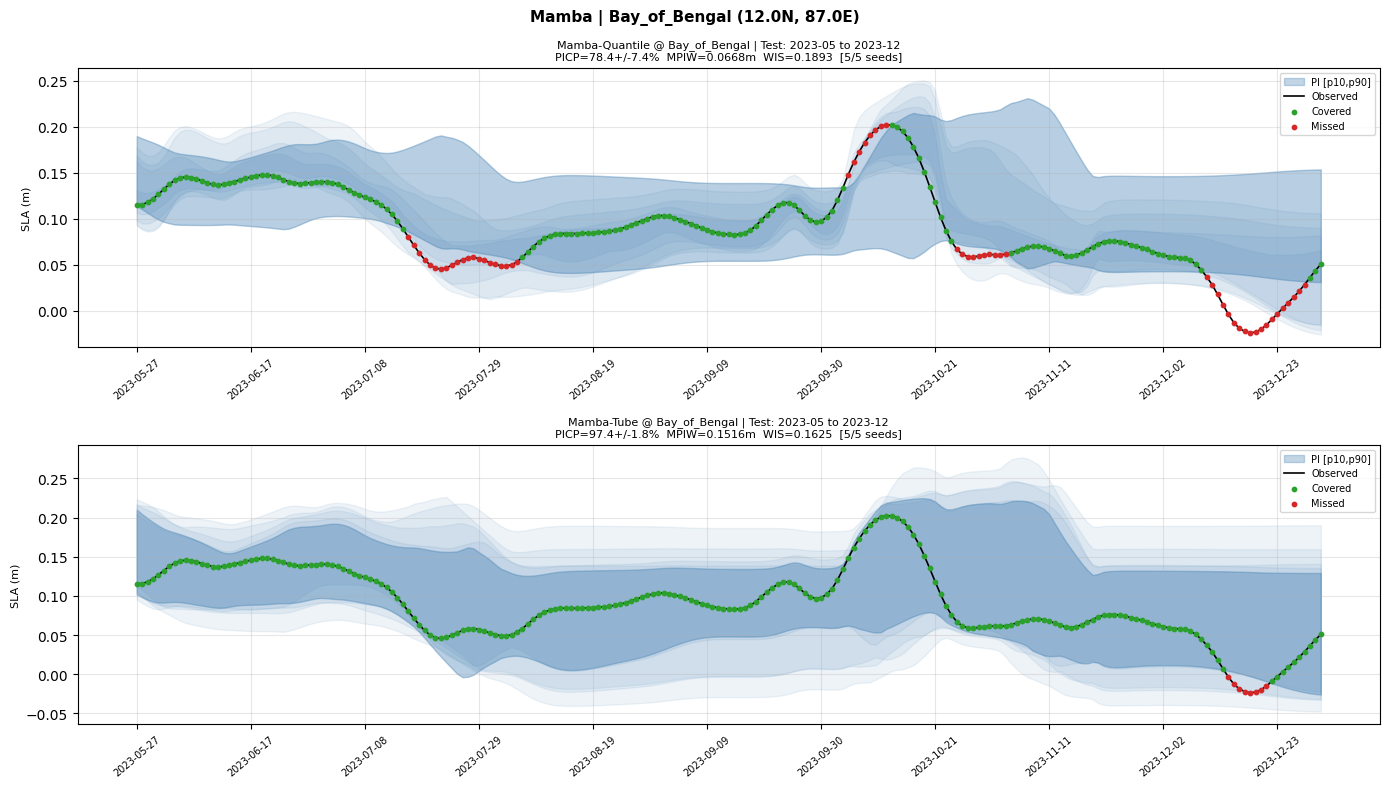

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_Mamba_Bay_of_Bengal.png


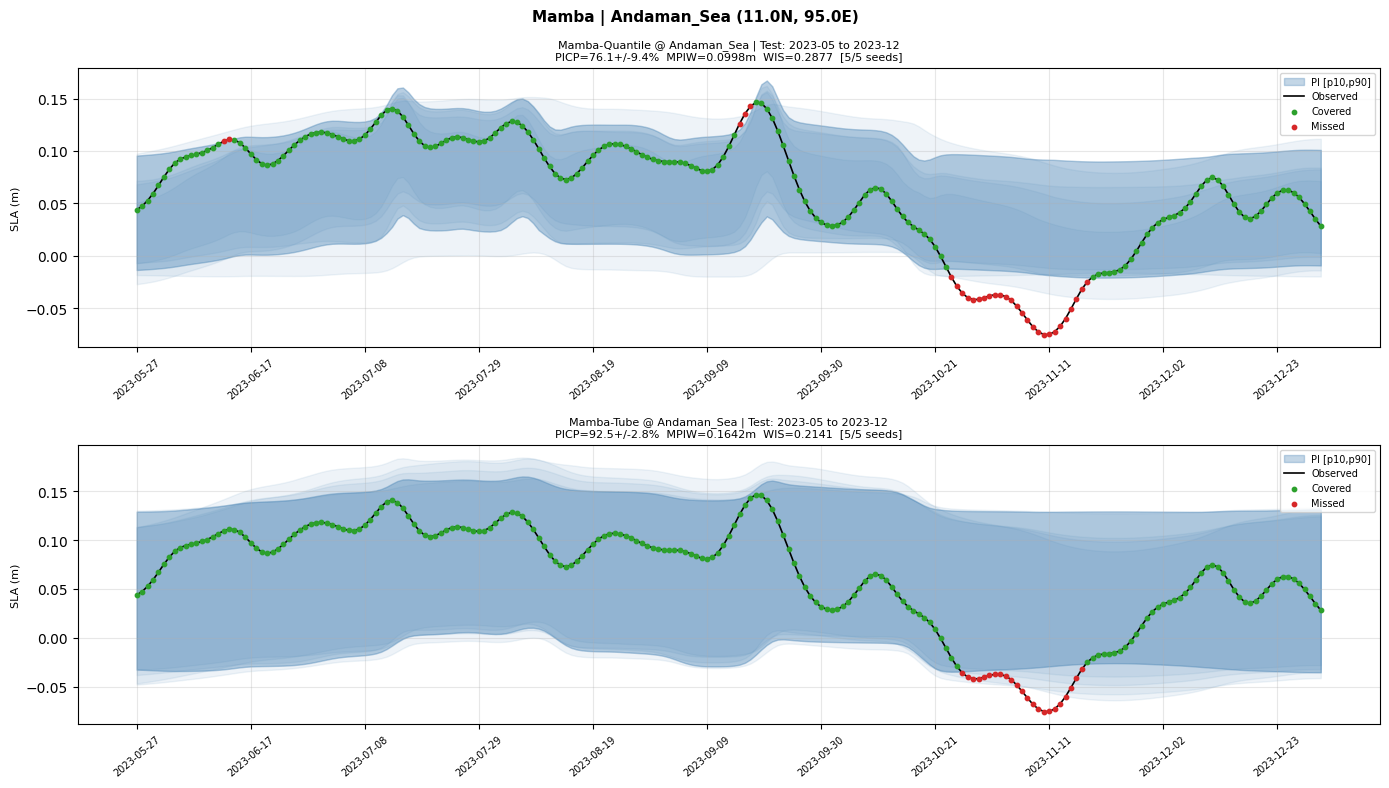

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_Mamba_Andaman_Sea.png


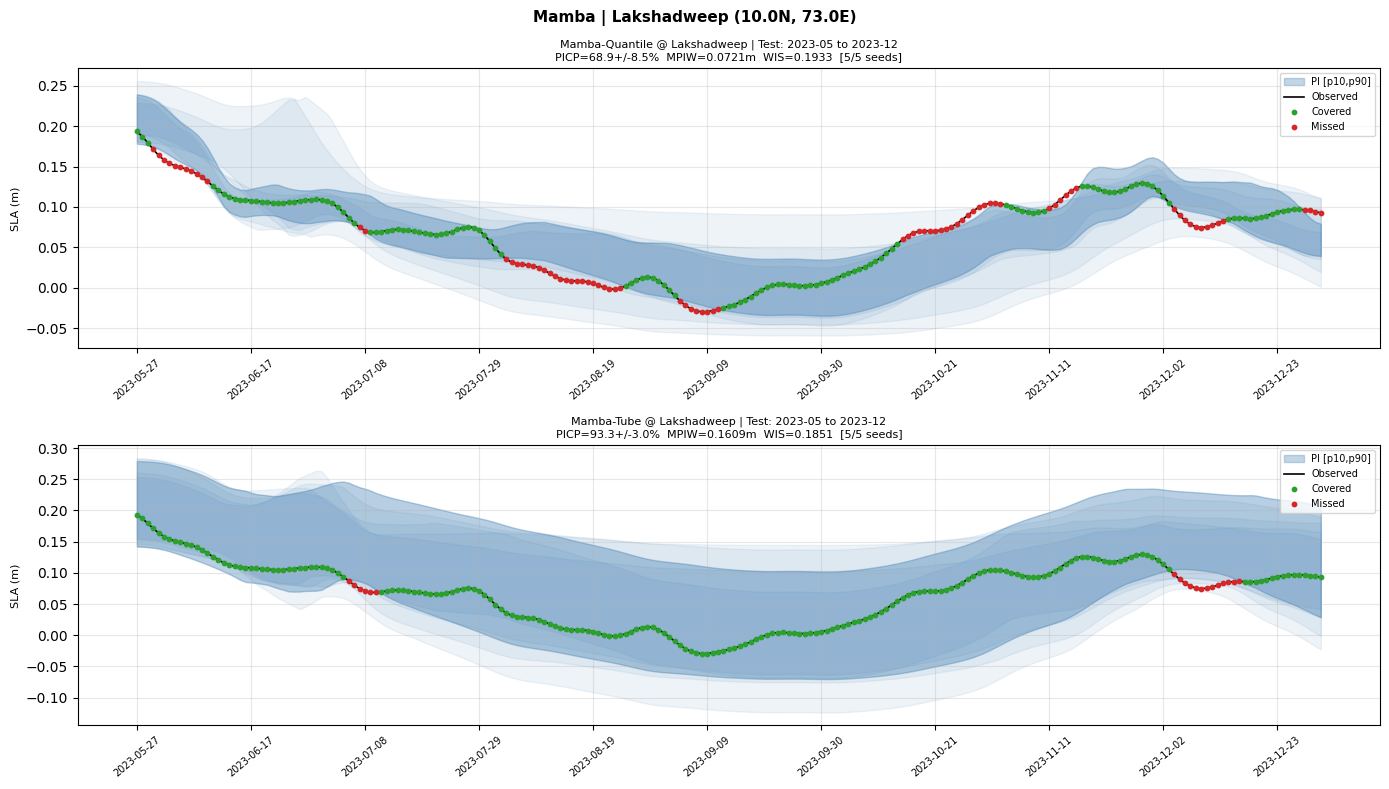

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_Mamba_Lakshadweep.png


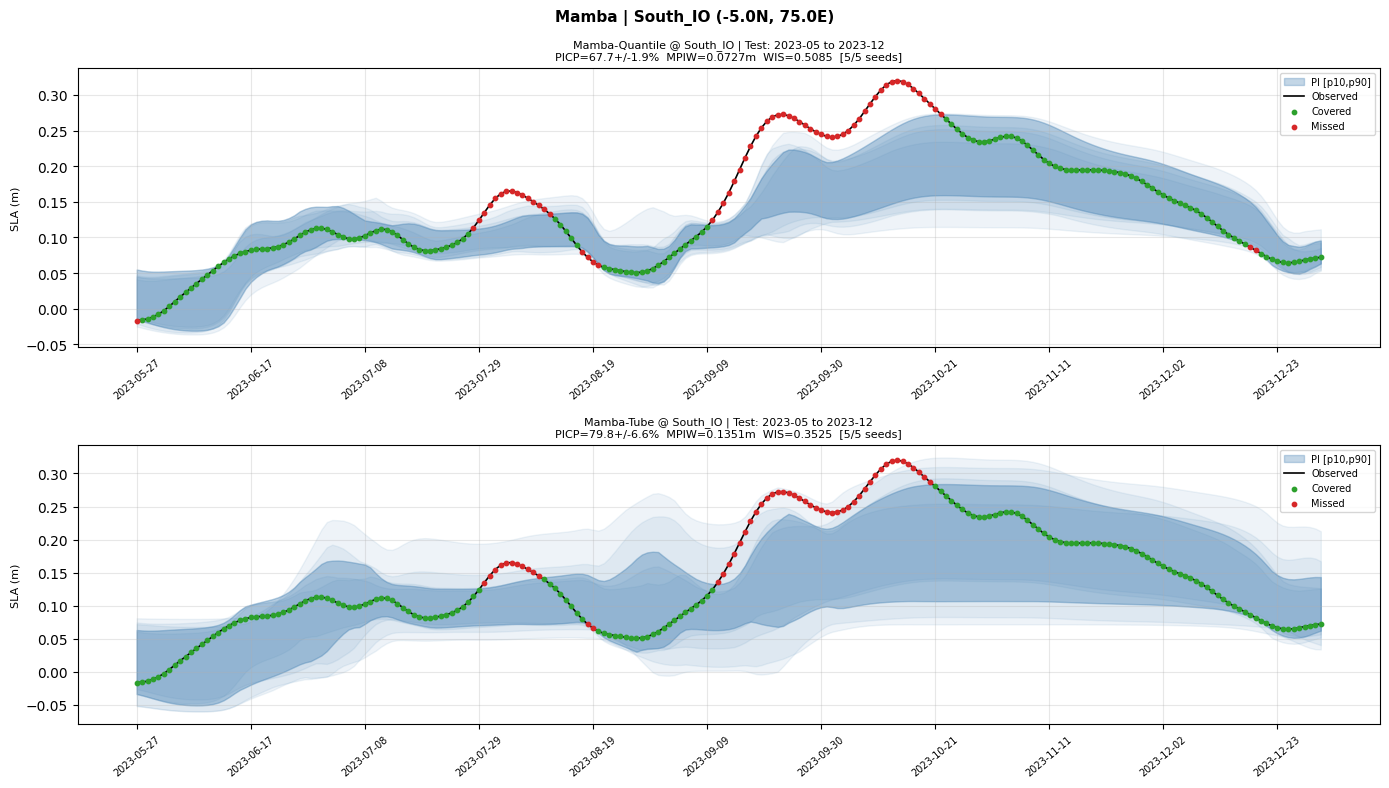

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\results_IndianOcean/plot_Mamba_South_IO.png


In [11]:
# ── Cell 6: Visualisation ────────────────────────────────────
print('Generating plots...')

for loc_name, (lat, lon) in LOCATIONS.items():
    sub = df[df['location'] == loc_name]
    model_ids = sub['model'].tolist()
    n_rows = len(model_ids)

    fig, axes = plt.subplots(n_rows, 1, figsize=(14, 4*n_rows))
    if n_rows == 1: axes = [axes]

    sla_raw = ds['sla'].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    sla_s   = pd.Series(sla_raw, index=times_index).interpolate(method='time', limit=14).ffill().bfill()
    n_train = int(len(sla_s)*TRAIN_SPLIT)
    t_times = times_index[n_train:]
    x_ax    = range(len(t_times))
    step    = max(1, len(t_times)//10)

    for ax, model_id in zip(axes, model_ids):
        row = sub[sub['model']==model_id].iloc[0]
        pd_ = all_preds.get(loc_name, {}).get(model_id, {})
        y_m = None

        for seed, (lo, hi, ym) in pd_.items():
            if y_m is None: y_m = ym
            if np.any(np.isnan(lo)): continue
            ax.fill_between(x_ax, lo, hi, alpha=0.09, color='steelblue')

        cands = [(abs(np.mean((ym >= lo) & (ym <= hi))*100 - row['avg_picp']), seed)
                 for seed in SEEDS if seed in pd_ and not np.any(np.isnan(pd_[seed][0]))]
        if cands:
            best = sorted(cands)[0][1]
            lo_b, hi_b, y_m = pd_[best]
            ax.fill_between(x_ax, lo_b, hi_b, alpha=0.32, color='steelblue', label='PI [p10,p90]')
            covered = (y_m >= lo_b) & (y_m <= hi_b)
            ax.plot(x_ax, y_m, 'k-', lw=1.2, label='Observed')
            ax.scatter(np.where(covered)[0],  y_m[covered],  color='#2ca02c', s=10, zorder=5, label='Covered')
            ax.scatter(np.where(~covered)[0], y_m[~covered], color='#d62728', s=10, zorder=5, label='Missed')

        ax.set_xticks(list(x_ax)[::step])
        ax.set_xticklabels([t_times[i].strftime('%Y-%m-%d') for i in range(0,len(t_times),step)],
                           rotation=40, fontsize=7)
        ax.set_ylabel('SLA (m)', fontsize=8)
        cal_tag = ' [CALIBRATED]' if row.get('calibrated', False) else ''
        ax.set_title(
            f'{model_id} @ {loc_name}{cal_tag} | Test: {row["test_period"]}\n'
            f'PICP={row["avg_picp"]:.1f}+/-{row["std_picp"]:.1f}%  '
            f'MPIW={row["avg_mpiw"]:.4f}m  WIS={row["avg_wis"]:.4f}  '
            f'[{row["n_valid_seeds"]}/{row["n_seeds"]} seeds]', fontsize=8)
        ax.legend(fontsize=7, loc='upper right'); ax.grid(True, alpha=0.3)

    fig.suptitle(f'{ARCH} | {loc_name} ({lat}N, {lon}E)', fontsize=11, fontweight='bold')
    plt.tight_layout()
    fp = os.path.join(SAVE_DIR, f'plot_{ARCH}_{loc_name}.png')
    plt.savefig(fp, dpi=110, bbox_inches='tight'); plt.show()
    print(f'  Saved: {fp}')

In [12]:
# ── Cell 7: Per-architecture Summary Table ───────────────────
print(f'\n{"="*100}')
print(f'  {ARCH} -- ALL LOCATIONS (calibrated rows marked *)')
print(f'{"="*100}')
print(f'  {"Location":<18} {"Model":<24} {"PICP%":>7} {"+/-":>5} {"MPIW(m)":>9} {"+/-":>8} '
      f'{"WIS":>8} {"r":>5} {"delta":>7} {"Cal":>4}')
print(f'  {"-"*100}')
for _, r in df.sort_values(["location","model"]).iterrows():
    r_s = f"{r['r']:.1f}"    if pd.notna(r['r'])     else "  --"
    d_s = f"{r['delta']:.3f}" if pd.notna(r['delta']) else "    --"
    w_s = f"{r['avg_wis']:.4f}" if pd.notna(r['avg_wis']) else "      --"
    cal = "  *" if r.get('calibrated', False) else "   "
    print(f'  {r["location"]:<18} {r["model"]:<24} '
          f'{r["avg_picp"]:7.1f} {r["std_picp"]:5.1f} '
          f'{r["avg_mpiw"]:9.4f} {r["std_mpiw"]:8.4f} '
          f'{w_s:>8} {r_s:>5} {d_s:>7} {cal}')


  Mamba -- ALL LOCATIONS (calibrated rows marked *)
  Location           Model                      PICP%   +/-   MPIW(m)      +/-      WIS     r   delta  Cal
  ----------------------------------------------------------------------------------------------------
  Andaman_Sea        Mamba-Quantile              76.1   9.4    0.0998   0.0223   0.2877    --      --    
  Andaman_Sea        Mamba-Tube                  92.5   2.8    0.1642   0.0052   0.2141   0.5   0.010    
  Arabian_Sea        Mamba-Quantile              77.5   6.2    0.0545   0.0042   0.1191    --      --    
  Arabian_Sea        Mamba-Tube                  91.8   1.8    0.0889   0.0090   0.1079   0.5   0.010    
  Bay_of_Bengal      Mamba-Quantile              78.4   7.4    0.0668   0.0259   0.1893    --      --    
  Bay_of_Bengal      Mamba-Tube                  97.4   1.8    0.1516   0.0281   0.1625   0.5   0.010    
  Lakshadweep        Mamba-Quantile              68.9   8.5    0.0721   0.0272   0.1933    --      --